# Introduction

This notebook is dedicated to implement the deconstruct the dynamical decoupling unitaries into combinations of pulses, implemented on the ionized antimony nucleus. 

We assume that the relevant noise is generated by fluctuations in the $I_z$ and the $I_z^2$ terms in the Hamiltonian.

To cancel the $I_z$ noise term, we should apply a decoupling sequence with: 

\begin{align}
    X_s = \left( \begin{array}{ccccc}
       0 &  0 & 0 & \dots & 1  \\
        0 &  0 & 0 & \dots & 0 \\
        \vdots & \vdots & \ddots & \vdots & \vdots \\
         0 & 1 & \ddots & 0 & 0 \\
         1 & 0 & \dots & 0 & 0 \\
    \end{array}\right),
\end{align}

which is just the Unitary generated by an $I_x$-$\pi$ rotation.

The $I_z^2$ term in cancelled by applying a decoupling sequence with the following three unitaries:

\begin{align}
\label{eq:ddsequence-quadrupole-traceless}
U_{1} = \left(
\begin{array}{cccccccc}
 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
\end{array}
\right), U_{2} = \left(
\begin{array}{cccccccc}
 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
\end{array}
\right), U_{3} = \left(
\begin{array}{cccccccc}
 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
\end{array}
\right).
\end{align}

Note: appying these unitaries would cancel the 'traceless' $\tilde{I}_z^2$ term. That is: $\tilde{I}_z^2 = I_z^2- Tr[I_z^2]/8$ 

How would we generate these unitaries using our methods of control?

# Imports

In [2]:
import numpy as np
from scipy.linalg import expm
from lmfit import Model, Parameters, minimize
import matplotlib.pyplot as plt
import qutip as qt
import lmfit as lm
from scipy.linalg import expm
from psyduck.plotting.wigner_plot import *

In [3]:
even = 0
odd = 0
for i in ([0, 2, 4, 6]):
    even += qt.ket2dm(basis(8, i))
    odd += qt.ket2dm(basis(8, i+1))

In [4]:
even

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]

In [5]:
odd

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]]

In [6]:
even-odd

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.]]

## helper functions

In [7]:
spin_dim = 7/2
Ix = qt.jmat(spin_dim,'x')
Iy = qt.jmat(spin_dim,'y')
Iz = qt.jmat(spin_dim,'z')
Iz2 = Iz*Iz

def subspace_rotation_arb_vec(spin_dim, angle, _n):
    """
    Calculates a rotation matrix in the subspace of a given spin system, with an arbitrary axis of rotation.

    Parameters:
    spin_dim (float): The spin dimension (e.g., 7/2 for a spin-7/2 system).
    angle (float): The angle of rotation in radians.
    _n (array-like): The rotation axis vector with 3 components (x, y, z).

    Returns:
    numpy.ndarray: The rotation matrix padded to size 8x8 with zeros.
    """
    d = int(spin_dim*2)+1
    _n_norm = np.linalg.norm(_n)
    _n = _n / _n_norm
    Rrot_exponent = 1j * angle * (_n[0]*Ix + _n[1]*Iy + _n[2]*Iz)
    Rrot = Rrot_exponent.expm()

    # Pad with zeros
    Rrot = np.pad(Rrot, (((8-d)//2, (8-d)//2), ((8-d)//2, (8-d)//2)), 'constant', constant_values=(0))
    return Rrot


def exponential(x, a, T2, exp, c):
    """
    Defines an exponential decay function.

    Parameters:
    x (array-like): The input values for which the exponential decay is calculated.
    a (float): The amplitude factor.
    T2 (float): The characteristic decay time constant.
    exp (float): The exponent for the decay term.
    c (float): A constant offset.

    Returns:
    numpy.ndarray: The calculated values of the exponential function for each input value in x.
    """
    return a*np.exp(-(x/T2)**exp) + c


def Hrf(drive, detuning=np.zeros(7), phase=np.zeros(7), cross_coupling=False):
    """
    Constructs the Hamiltonian in the rotating frame for a spin system with multiple driving frequencies.

    Parameters:
    drive (array-like): Array of 7 driving amplitudes for the transitions.
    detuning (array-like, optional): Array of 7 frequency detunings (Hz) between the driving frequencies and the NMR frequencies. Default is zeros.
    phase (array-like, optional): Array of 7 phase offsets for the driving frequencies. Default is zeros.
    cross_coupling (bool, optional): If True, includes cross-coupling between different transitions. Default is False.

    Returns:
    qutip.Qobj: The Hamiltonian as a QuTiP quantum object. If cross_coupling is False, the Hamiltonian is time-independent.
    """
    Ix_coupling = np.diag(Ix.full(), 1)
    df = np.zeros((7,7))     
    Hnp = np.zeros((8,8), dtype=np.complex128)

    # Detuning terms
    for i in range(0, 7):
        Hnp[i+1, i+1] = Hnp[i, i] + detuning[i] * 2 * np.pi

    for i in range(7):
        Hnp[i, i+1] += drive[i] * Ix_coupling[i] * np.exp(1j * phase[i])
        Hnp[i+1, i] += drive[i] * Ix_coupling[i] * np.exp(-1j * phase[i])

    return qt.Qobj(Hnp)


def perm(element1, element2, d=8):
    """
    Generates a permutation matrix that swaps two elements in a matrix.

    Parameters:
    element1 (int): Index of the first element to swap.
    element2 (int): Index of the second element to swap.
    d (int, optional): The dimension of the matrix. Default is 8.

    Returns:
    numpy.ndarray: A permutation matrix that swaps the elements at indices element1 and element2.
    """
    U = np.eye(d)
    U[element1, element2] = 1
    U[element2, element1] = 1
    U[element1, element1] = 0
    U[element2, element2] = 0
    return qt.Qobj(U)


def calculate_subspace_rotation_amplitudes(subspace_size, starting_state):
    """
    Calculates the relative drive amplitudes required for rotating within a subspace of a spin system.

    Parameters:
    subspace_size (int): The size of the subspace.
    starting_state (int): The starting state of the subspace.

    Returns:
    numpy.ndarray: The relative amplitudes for driving the transitions within the subspace.
    
    Raises:
    Exception: If the subspace size and starting state exceed the system size (8).
    """
    if subspace_size + starting_state > 8:
        raise Exception("Invalid Subspace size/Starting state")

    relative_amplitudes = np.zeros(7)
    subspace_array = np.arange(starting_state, starting_state + subspace_size - 1)
    desired_Ix = np.real(np.diag(qt.jmat((subspace_size - 1) / 2, "x").full(), 1)).tolist()
    desired_Ix_padding = [0] * starting_state + desired_Ix
    normalisation_Ix = np.real(np.diag(qt.jmat(7 / 2, "x").full(), 1))

    for d in subspace_array:
        relative_amplitudes[d] = desired_Ix_padding[d] / normalisation_Ix[d]
    return relative_amplitudes


def snap(phases, d=8):
    """
    Generates a unitary matrix that applies a phase shift to each diagonal element of the matrix.

    Parameters:
    phases (array-like): Array of phase shifts to be applied.
    d (int, optional): The dimension of the matrix. Default is 8.

    Returns:
    numpy.ndarray: A unitary matrix with the specified phase shifts applied.
    """
    U = np.eye(d, dtype=np.complex128)
    for i, p in enumerate(phases):
        U[i, i] = np.exp(1j*p)
    return qt.Qobj(U)

def rot(angle, initial_state, target_state, phase=0):
    """
    Constructs a rotation matrix for an arbitrary angle between two states of a spin-7/2 system.

    Parameters:
    angle (float): The angle of rotation in radians.
    initial_state (int): The initial state of the system.
    target_state (int): The target state after the rotation.
    phase (float or array-like, optional): Phase offset for the rotation. Default is 0.

    Returns:
    numpy.ndarray: The resulting unitary matrix from the rotation by the specified angle.
    """
    amps = calculate_subspace_rotation_amplitudes(target_state - initial_state + 1, initial_state)
#     print('drive amplitudes: \n', amps)
    if type(phase) == float or type(phase) == int:
        phase = np.repeat(phase, len(amps))
#     print('phases: \n', phase)
    return qt.Qobj(expm(1j * angle * Hrf(amps, phase=phase).full()))

def pi(initial_state, target_state, phase=0):
    """
    Constructs a rotation matrix for a π (pi) pulse between two states of a spin-7/2 system.

    Parameters:
    initial_state (int): The initial state of the system.
    target_state (int): The target state after the π rotation.
    phase (float or array-like, optional): Phase offset for the rotation. Default is 0.

    Returns:
    numpy.ndarray: The resulting unitary matrix from the π pulse.
    """
    return rot(np.pi, initial_state, target_state, phase)

def frame_update(clock_phases):
    """
    Constructs a unitary matrix that updates the frame of reference based on clock phases for a spin system.

    Parameters:
    clock_phases (array-like): A sequence of clock phases applied to the system. Each phase corresponds to a transition.

    Returns:
    qutip.Qobj: A QuTiP quantum object representing the unitary matrix with phase shifts applied to the diagonal elements.
    The phases accumulate progressively, with each element's phase shift being the sum of all preceding phases.
    """
    U = np.eye(8, dtype=np.complex128)
    for i, p in enumerate(clock_phases):
        U[i+1, i+1] = np.exp(1j*np.sum(clock_phases[0:i+1]))
    return qt.Qobj(U)


In [8]:
cat = (qt.basis(8, 0) + qt.basis(8,7)).unit()
cat_y = rot(np.pi/2, 0, 7, phase=0)*cat

In [9]:
qt.ket2dm(cat_y)

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.0078125  -0.02066993 -0.03580137  0.04621937  0.04621937 -0.03580137
  -0.02066993  0.0078125 ]
 [-0.02066993  0.0546875   0.09472153 -0.12228497 -0.12228497  0.09472153
   0.0546875  -0.02066993]
 [-0.03580137  0.09472153  0.1640625  -0.21180378 -0.21180378  0.1640625
   0.09472153 -0.03580137]
 [ 0.04621937 -0.12228497 -0.21180378  0.2734375   0.2734375  -0.21180378
  -0.12228497  0.04621937]
 [ 0.04621937 -0.12228497 -0.21180378  0.2734375   0.2734375  -0.21180378
  -0.12228497  0.04621937]
 [-0.03580137  0.09472153  0.1640625  -0.21180378 -0.21180378  0.1640625
   0.09472153 -0.03580137]
 [-0.02066993  0.0546875   0.09472153 -0.12228497 -0.12228497  0.09472153
   0.0546875  -0.02066993]
 [ 0.0078125  -0.02066993 -0.03580137  0.04621937  0.04621937 -0.03580137
  -0.02066993  0.0078125 ]]

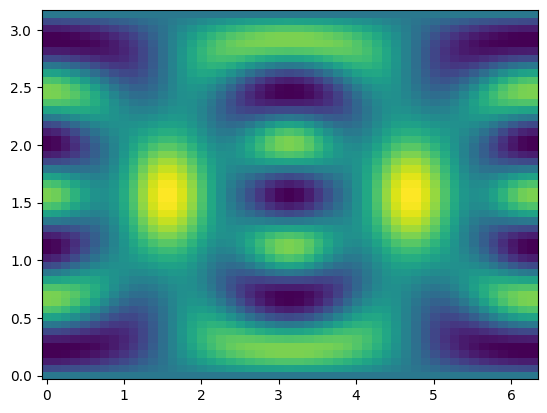

In [10]:
theta = np.linspace(0, np.pi, 50)
phi = np.linspace(0, np.pi*2, 51)
wigner, theta_mesh, phi_mesh = qt.spin_wigner(cat_y, theta, phi)
plt.pcolor(phi, theta, wigner.T)

In [11]:
def wigner_plot(rho,dpi=300):
    nTheta, nPhi = (101, 201)
    theta = np.linspace(0, np.pi, num=nTheta, endpoint=True)
    phi = np.linspace(-np.pi, np.pi, num=nPhi, endpoint=True)
    husimi0, theta_mesh, phi_mesh = spin_wigner(rho, theta, phi)

    r = 1
    x = r*np.cos(phi_mesh)*np.cos(theta_mesh-np.pi/2)
    y = r*np.sin(phi_mesh)*np.cos(theta_mesh-np.pi/2)
    z = r*np.sin(theta_mesh-np.pi/2)

    fig = plt.figure(figsize=(8, 3))
    ax = fig.add_subplot(1, 2, 1, projection='3d')

    cmap = mpl.cm.bwr
    norm = mpl.colors.Normalize(vmin=husimi0.min(), vmax=husimi0.max())
    ax.plot_surface(x, y, z, facecolors=cmap(norm(husimi0)), rstride=1, cstride=1, shade=False)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    # ax.plot_surface(x,y,z, rstride=1, cstride=1)

#     ax.set_axis_off()
    s = 0.7 # plot_scale
    ax.set_xlim([-s,s])
    ax.set_ylim([-s,s])
    ax.set_zlim([-s,s])
    ax = fig.add_subplot(1, 2, 2, projection='hammer')
    ax.pcolormesh(phi_mesh, theta_mesh - np.pi/2, husimi0, cmap='bwr')
    ax.set_xticklabels([])


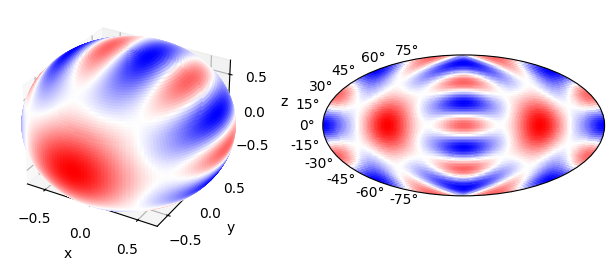

In [12]:
wigner_plot(cat_y)

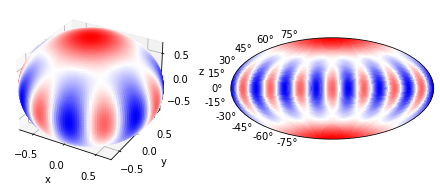

In [12]:
cat = (qt.basis(8, 0) + qt.basis(8, 7)).unit()
wigner_plot(cat)

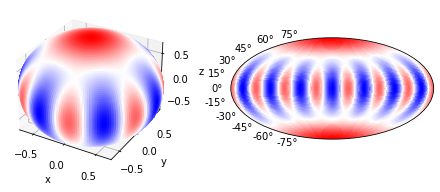

In [13]:
cat_ = (qt.basis(8, 0) - qt.basis(8, 7)).unit()
wigner_plot(cat_)

In [14]:
qt.fidelity(cat, cat_)

0.0

In [13]:
f_t = qt.Qobj(expm(-1j*Iz2.full()))
f_t

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.95037085+0.31111935j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.99944942+0.03317922j  0.        +0.j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j         -0.62817362-0.7780732j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.96891242-0.24740396j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.96891242-0.24740396j  0.        +0.j
   0.        +0.j          0.  

In [14]:
f_t = qt.Qobj(expm(-1j*Iz2.full()))
f_t2 = qt.Qobj(expm(-1j*2*Iz2.full()))
f_t * rot(np.pi/2, 0, 7, phase=0) * f_t * rot(np.pi/2, 0, 7, phase=np.pi/2) * f_t2 * rot(-np.pi/2, 0, 7, phase=np.pi/2) * f_t * rot(-np.pi/2, 0, 7,phase=0)

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 2.40355338e-03+6.65932850e-01j  2.80282104e-16+2.50253836e-16j
   1.25237148e-02+8.02105911e-03j -1.01784028e-17+2.87410650e-16j
   6.12894636e-01-3.38032704e-01j -7.65613733e-17-4.57686193e-17j
   2.57050295e-01-1.80467243e-02j -1.65824104e-16-9.07632431e-17j]
 [-4.84084998e-16+1.26385263e-16j -5.02487607e-01+7.22757969e-01j
  -2.09109537e-17+2.81805384e-16j  2.41764053e-01-1.63748743e-01j
   4.37886930e-16-4.50099799e-17j -2.57120365e-01+8.57449366e-02j
   1.16081500e-16-1.03296147e-18j  2.41769521e-01-8.91517648e-02j]
 [-6.14466703e-03-1.35434076e-02j  5.88228030e-17+2.84513762e-16j
  -4.09543929e-01-8.67881147e-01j -3.60543857e-17-3.45243482e-16j
  -7.04007534e-02-2.03853328e-02j -3.49561368e-17+9.22342982e-18j
   2.32957068e-01+1.38542703e-01j -4.60348771e-16+2.15088304e-16j]
 [ 5.94362420e-17-3.31496440e-17j  1.86380723e-01-2.24779301e-01j
  -1.27565214e-16-2.69071938e-16j  6.3902

In [17]:
f_t = qt.Qobj(expm(-1j*Iz2.full()))
f_t2 = qt.Qobj(expm(-1j*2*Iz2.full()))
f_t * rot(np.pi/2, 0, 7, phase=0)* f_t * rot(np.pi/2, 0, 7, phase=np.pi/2) * f_t2 * rot(-np.pi/2, 0, 7, phase=np.pi/2)* f_t* rot(-np.pi/2, 0, 7, phase=0)*f_t

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[-0.20490033+0.63363096j  0.        +0.j         -0.0016261 -0.01478298j
   0.        +0.j          0.5102106 -0.47915664j  0.        +0.j
   0.25750754-0.00950806j  0.        +0.j        ]
 [ 0.        +0.j         -0.52619149+0.70568789j  0.        +0.j
   0.19373611-0.21847157j  0.        +0.j          0.22823207+0.14619576j
   0.        +0.j          0.25750754-0.00950806j]
 [-0.0016261 -0.01478298j  0.        +0.j         -0.41801037+0.8638352j
   0.        +0.j         -0.07325558-0.00233418j  0.        +0.j
   0.22823207+0.14619576j  0.        +0.j        ]
 [ 0.        +0.j          0.19373611-0.21847157j  0.        +0.j
   0.64523173-0.05598871j  0.        +0.j         -0.07325558-0.00233418j
   0.        +0.j          0.5102106 -0.47915664j]
 [ 0.5102106 -0.47915664j  0.        +0.j         -0.07325558-0.00233418j
   0.        +0.j          0.64523173-0.05598871j  0.        +0.j
   0.1

In [18]:
f_t

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.95037085+0.31111935j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.99944942+0.03317922j  0.        +0.j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j         -0.62817362-0.7780732j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.96891242-0.24740396j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.96891242-0.24740396j  0.        +0.j
   0.        +0.j          0.        +

In [19]:
I_plus = qt.jmat(7/2, '+')
I_plus * I_plus

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.          0.          9.16515139  0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.         13.41640786  0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.         15.49193338  0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.         15.49193338
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
  13.41640786  0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          9.16515139]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]]

In [20]:
np.diag((I_plus * I_plus).full(), 2)

array([ 9.16515139+0.j, 13.41640786+0.j, 15.49193338+0.j, 15.49193338+0.j,
       13.41640786+0.j,  9.16515139+0.j])

In [21]:
step1 = -2*rot(-np.pi/2, 0, 7, phase=0)*Iz2*rot(np.pi/2, 0, 7, phase=0) + (3.5 + 12.25)*qt.identity(8)
np.diag((step1).full(), 2) / np.diag((I_plus * I_plus).full(), 2)

array([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j])

In [22]:
-2*rot(-np.pi/2, 0, 7, phase=0)*rot(-np.pi/2, 0, 7, phase=np.pi/2)*Iz2*rot(np.pi/2, 0, 7, phase=np.pi/2)*rot(np.pi/2, 0, 7, phase=0) + 3.5 + 12.25

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[12.25        0.         -4.58257569  0.          0.          0.
   0.          0.        ]
 [ 0.          6.25        0.         -6.70820393  0.          0.
   0.          0.        ]
 [-4.58257569  0.          2.25        0.         -7.74596669  0.
   0.          0.        ]
 [ 0.         -6.70820393  0.          0.25        0.         -7.74596669
   0.          0.        ]
 [ 0.          0.         -7.74596669  0.          0.25        0.
  -6.70820393  0.        ]
 [ 0.          0.          0.         -7.74596669  0.          2.25
   0.         -4.58257569]
 [ 0.          0.          0.          0.         -6.70820393  0.
   6.25        0.        ]
 [ 0.          0.          0.          0.          0.         -4.58257569
   0.         12.25      ]]

In [23]:
step1

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[12.25        0.          4.58257569  0.          0.          0.
   0.          0.        ]
 [ 0.          6.25        0.          6.70820393  0.          0.
   0.          0.        ]
 [ 4.58257569  0.          2.25        0.          7.74596669  0.
   0.          0.        ]
 [ 0.          6.70820393  0.          0.25        0.          7.74596669
   0.          0.        ]
 [ 0.          0.          7.74596669  0.          0.25        0.
   6.70820393  0.        ]
 [ 0.          0.          0.          7.74596669  0.          2.25
   0.          4.58257569]
 [ 0.          0.          0.          0.          6.70820393  0.
   6.25        0.        ]
 [ 0.          0.          0.          0.          0.          4.58257569
   0.         12.25      ]]

In [24]:
np.sqrt(3/8)*np.diag(Iz2.full())

array([7.50156234+0.j, 3.82732772+0.j, 1.37783798+0.j, 0.15309311+0.j,
       0.15309311+0.j, 1.37783798+0.j, 3.82732772+0.j, 7.50156234+0.j])

In [25]:
-2*rot(-np.pi/2, 0, 7, phase=0)*Iz2*rot(np.pi/2, 0, 7, phase=0) + (3.5 + 12.25)*qt.identity(8)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[12.25        0.          4.58257569  0.          0.          0.
   0.          0.        ]
 [ 0.          6.25        0.          6.70820393  0.          0.
   0.          0.        ]
 [ 4.58257569  0.          2.25        0.          7.74596669  0.
   0.          0.        ]
 [ 0.          6.70820393  0.          0.25        0.          7.74596669
   0.          0.        ]
 [ 0.          0.          7.74596669  0.          0.25        0.
   6.70820393  0.        ]
 [ 0.          0.          0.          7.74596669  0.          2.25
   0.          4.58257569]
 [ 0.          0.          0.          0.          6.70820393  0.
   6.25        0.        ]
 [ 0.          0.          0.          0.          0.          4.58257569
   0.         12.25      ]]

In [26]:
Iz2

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[12.25  0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    6.25  0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    2.25  0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.25  0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.25  0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    2.25  0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    6.25  0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.   12.25]]

In [27]:
rot(np.pi/2, 0, 7, phase=0)* rot(np.pi/2, 0, 7, phase=np.pi/2) * rot(-np.pi/2, 0, 7, phase=np.pi/2)* rot(-np.pi/2, 0, 7, phase=0)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]]

In [28]:
np.diag(np.array(qt.jmat(7/2, 'x')), 1)

array([1.32287566+0.j, 1.73205081+0.j, 1.93649167+0.j, 2.        +0.j,
       1.93649167+0.j, 1.73205081+0.j, 1.32287566+0.j])

# Examples of constructing pulses

We can create the unitary of a pi pulse simply by calling 'pi' on two elements. It prints the amplitudes needed to create the unitary

## 2-level pi

In [29]:
psi=0
for i in range(8):
    psi += qt.basis(8, i)
psi = psi.unit()

In [30]:
psi*psi.dag()

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]]

In [31]:
U1*basis(8, 7)

NameError: name 'U1' is not defined

In [32]:
pi(6, 7)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+1.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+1.j 0.+0.j]]

We can add a phase as well. 

In [33]:
pi(6,7, phase=np.pi/2)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 1.+0.00000000e+00j  0.+0.00000000e+00j  0.+0.00000000e+00j
   0.+0.00000000e+00j  0.+0.00000000e+00j  0.+0.00000000e+00j
   0.+0.00000000e+00j  0.+0.00000000e+00j]
 [ 0.+0.00000000e+00j  1.+0.00000000e+00j  0.+0.00000000e+00j
   0.+0.00000000e+00j  0.+0.00000000e+00j  0.+0.00000000e+00j
   0.+0.00000000e+00j  0.+0.00000000e+00j]
 [ 0.+0.00000000e+00j  0.+0.00000000e+00j  1.+0.00000000e+00j
   0.+0.00000000e+00j  0.+0.00000000e+00j  0.+0.00000000e+00j
   0.+0.00000000e+00j  0.+0.00000000e+00j]
 [ 0.+0.00000000e+00j  0.+0.00000000e+00j  0.+0.00000000e+00j
   1.+0.00000000e+00j  0.+0.00000000e+00j  0.+0.00000000e+00j
   0.+0.00000000e+00j  0.+0.00000000e+00j]
 [ 0.+0.00000000e+00j  0.+0.00000000e+00j  0.+0.00000000e+00j
   0.+0.00000000e+00j  1.+0.00000000e+00j  0.+0.00000000e+00j
   0.+0.00000000e+00j  0.+0.00000000e+00j]
 [ 0.+0.00000000e+00j  0.+0.00000000e+00j  0.+0.00000000e+00j
   0.+0.0000

## multi-level pi

To generate a multi-level pi pulse, we should simulaneously drive multiple transition frequencies with amplitudes adjusted to match the I_x operator in the subspace.

In [34]:
pi(3, 7)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 1.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  1.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   1.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  6.24500451e-17

## frame update

The frame updates, done in harware by shifting the 7 clock phases, will generate a diagonal unitary where the phases of the elements are given by the cumulative sum of all previous clock phases. See the two examples below:

Here, a clock shift on the 3rd transition element (the transition coupling states -3/2 -> -1/2), induces a phase shift on the entire subspace from -1/2 onwards. 

In [35]:
clock_phases = [0, 0, np.pi/2, 0, 0, 0, 0]
frame_update(clock_phases)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[1.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j
  0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 1.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j
  0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 1.000000e+00+0.j 0.000000e+00+0.j
  0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 6.123234e-17+1.j
  0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j
  6.123234e-17+1.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j
  0.000000e+00+0.j 6.123234e-17+1.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+

If we would like, for instance, only to have a phase shift on the -1/2 element, we should counteract the phase shift on subsequent elements as follows:

In [36]:
clock_phases = [0, 0, np.pi/2, -np.pi/2, 0, 0, 0]
frame_update(clock_phases)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[1.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j
  0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 1.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j
  0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 1.000000e+00+0.j 0.000000e+00+0.j
  0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 6.123234e-17+1.j
  0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j
  1.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j
  0.000000e+00+0.j 1.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+

It's clear that these frame updates generate the snap gates: 

In [37]:
snap([0, 0, 0, np.pi/2, 0, 0, 0])

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[1.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j
  0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 1.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j
  0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 1.000000e+00+0.j 0.000000e+00+0.j
  0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 6.123234e-17+1.j
  0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j
  1.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j
  0.000000e+00+0.j 1.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+00+0.j 0.000000e+

## create permutation matrix (without phase)

We can combine frame updates and pi pulses to create the permutation matrices needed for the dynamical decoupling sequences.

I'm not sure yet if the phases matter!

In [38]:
clock_phases = [0, 0, 0, 0, 0, -np.pi/2, 0]
pi(6,7)*frame_update(clock_phases)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]]

# Unitaries for $\tilde{I}_z^2$

## U1

We can create the upper left block by (0 1)(1 3)(2 3) permutations. Let's not care about the phases for now

In [39]:
U1 = perm(0,1) * perm(1,3) * perm(2,3) * perm(4,5) * perm(5,7) * perm(6,7)

In [40]:
U1

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0.]]

In [41]:
U1 = pi(0,1) * pi(1,3) * pi(2,3)
U1

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j]]

by subspace symmetry, we can easily see that the whole thing is created by the following:

In [42]:
pi(5,7)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 1.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  1.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   1.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  1.00000000e+00

In [43]:
U1 = pi(0,1) * pi(1,3) * pi(2,3) * pi(4,5) * pi(5,7) * pi(6,7)
U1

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+1.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.-1.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j]]

## U2 

U2 is interesting, and can simply be done by two subspace multi-level pi pulses, which can even be applied simultaneously.

In [44]:
U2 = pi(0, 3) * pi(4, 7)
U2

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j]]

## U3

U3 is the transpose of U1, so this is generated by applying the permutations in reverse

In [45]:
U3 = U1.dag()
U3

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.+0.j  0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.-1.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+1.j  0.+0.j]]

In [46]:
U3 = pi(2,3) * pi(1,3) * pi(0,1) * pi(6,7) * pi(5,7) * pi(4,5)
U3

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.+0.j  0.+1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+1.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.-1.j  0.+0.j]]

# Sign change due to decoupling sequence

## Iz

Let's see if the dynamical decoupling sequences actually cause a sign change in the relevant noise term in the system-bath hamiltonian

In [47]:
Iz

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 3.5  0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   2.5  0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   1.5  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.5  0.   0.   0.   0. ]
 [ 0.   0.   0.   0.  -0.5  0.   0.   0. ]
 [ 0.   0.   0.   0.   0.  -1.5  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.  -2.5  0. ]
 [ 0.   0.   0.   0.   0.   0.   0.  -3.5]]

In [48]:
pi(0, 7)*Iz*pi(0, 7).dag()

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[-3.5  0.   0.   0.   0.   0.   0.   0. ]
 [ 0.  -2.5  0.   0.   0.   0.   0.   0. ]
 [ 0.   0.  -1.5  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  -0.5  0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.5  0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   1.5  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   2.5  0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   3.5]]

That works indeed.

## $I_z^2$

In [49]:
Iz**2

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[12.25  0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    6.25  0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    2.25  0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.25  0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.25  0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    2.25  0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    6.25  0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.   12.25]]

In [50]:
Iz_2_traceless = Iz**2 - np.trace(Iz**2) / 8
Iz_2_traceless

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 7.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -3.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -5.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -5.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -3.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  7.]]

In [51]:
U1 * Iz_2_traceless * U1.dag() + U2 * Iz_2_traceless * U2.dag() + U3 * Iz_2_traceless * U3.dag()

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[-7.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  3.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  5.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  5.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  3.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -7.]]

That works too. So the phases didn't matter!

### non-traceless

what if $I_z^2$ were just the ordinary term, not the traceless one. What would happen to the matrix under influence of the dynamical decoupling sequence?

In [52]:
U1 * Iz**2 * U1.dag() + U2 * Iz**2 * U2.dag() + U3 * Iz**2 * U3.dag()

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 8.75  0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.   14.75  0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.   18.75  0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.   20.75  0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.   20.75  0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.   18.75  0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.   14.75  0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    8.75]]

Looks like it's absolutely necessary to implement the tracelessness. But how can it be done in real life?

### effect on $I_z$

In [53]:
U1 * Iz * U1.dag() + U2 * Iz * U2.dag() + U3 * Iz * U3.dag()

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 4.5  0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   5.5  0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   6.5  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   7.5  0.   0.   0.   0. ]
 [ 0.   0.   0.   0.  -7.5  0.   0.   0. ]
 [ 0.   0.   0.   0.   0.  -6.5  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.  -5.5  0. ]
 [ 0.   0.   0.   0.   0.   0.   0.  -4.5]]

# simplify DD sequence

The dynamical decoupling sequence is: 
\begin{equation}
f_\tau U_1 f_\tau U_1^\dagger U_2 f_\tau U_2 ^ \dagger U_3 f_\tau U_3 ^ \dagger = \mathcal{I}
\end{equation}

this simplifies because $U_1^\dagger U_2 = U_1$, also $U_2^\dagger U_3 = U_1$ and $U_3^\dagger = U_1$. So the DD sequence simplifies to this (!):

\begin{equation}
f_\tau U_1 f_\tau U_1 f_\tau U_1 f_\tau U_1 = \mathcal{I}
\end{equation}

## for traceless $I_z^2$ 

In [54]:
expm(1j*Iz*np.pi)*(basis(8, 2) + basis(8,3).unit())

array([[ 0.0000000e+00+0.j],
       [ 0.0000000e+00+0.j],
       [-1.8369702e-16-1.j],
       [ 6.1232340e-17+1.j],
       [ 0.0000000e+00+0.j],
       [ 0.0000000e+00+0.j],
       [ 0.0000000e+00+0.j],
       [ 0.0000000e+00+0.j]])

In [55]:
f_t = qt.Qobj(expm(-1j*Iz))
U1 * f_t * U1 * f_t * U1 * f_t * U1 * f_t

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[0.14550003+0.98935825j 0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.14550003+0.98935825j 0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.14550003+0.98935825j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.14550003+0.98935825j 0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.14550003-0.98935825j 0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0

In [56]:
f_t * pi(0, 7) * f_t * pi(0, 7)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[-1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.]]

In [57]:
f_t = qt.Qobj(1j*expm(Iz_2_traceless)*1)
f_t_half = qt.Qobj(1j*expm(Iz_2_traceless)*0.5)
f_t * U1 * f_t * U1 * f_t * U1 * f_t * U1

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[-1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.]]

Yes, this is indeed the identity matrix

In [58]:
U1*U1*U1*U1

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[-1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.]]

In [59]:
U1 * f_t * U1 * f_t * U1 * f_t * U1 * f_t

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[-1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.]]

In [60]:
(f_t * U1 * 2*f_t * U1 * f_t)**4

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[8.73570401e+02 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.93050222e-01 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 2.93050222e-01 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 8.73570401e+02
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  8.73570401e+02 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 2.93050222e-01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 2.93050222e-01 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.0

## for non-traceless $I_z^2$

In [61]:
f_t = qt.Qobj(expm(-1j*Iz**2))
f_t

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.95037085+0.31111935j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.99944942+0.03317922j  0.        +0.j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j         -0.62817362-0.7780732j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.96891242-0.24740396j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.96891242-0.24740396j  0.        +0.j
   0.        +0.j          0.        +

In [62]:
f_t * U1 * f_t * U1 * f_t * U1 * f_t * U1

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[0.54772926+0.83665564j 0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.54772926+0.83665564j 0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.54772926+0.83665564j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.54772926+0.83665564j 0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.54772926+0.83665564j 0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0

# concatenated sequence

## I_z

In [63]:
f_t = qt.Qobj(expm(-1j*Iz))
f_t * U1 * f_t * U1 * f_t * U1 * f_t * U1 * pi(0, 7) * f_t * U1 * f_t * U1 * f_t * U1 * f_t * U1 * pi(0, 7)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[-1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.]]

In [64]:
f_t = qt.Qobj(expm(-1j*(Iz+Iz_2_traceless)))
f_t * U1 * f_t * U1 * f_t * U1 * f_t * U1 * pi(0, 7)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.98935825-0.14550003j]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.98935825-0.14550003j  0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j          0.98935825-0.14550003j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.98935825-0.14550003j  0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
  -0.98935825-0.14550003j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        

This is also a scaled version of the identity matrix (!)

## I_z^2

In [65]:
f_t = qt.Qobj(expm(-1j*Iz_2_traceless))
f_t * U1 * f_t * U1 * f_t * U1 * f_t * U1 * pi(0, 7) * f_t * U1 * f_t * U1 * f_t * U1 * f_t * U1

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]

# Appendix matrix equalities ..

Below some display of the equalities of matrices

In [66]:
U1.dag()*U2

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+1.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.-1.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j]]

In [67]:
U1

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+1.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.-1.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j]]

In [68]:
U2.dag() * U3

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+1.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.-1.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j]]

In [69]:
U1

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+1.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.-1.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j]]

In [70]:
U3.dag()

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.-1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.-1.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+1.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j]]

# Clock and Shift DD

In [202]:
def hw_group(d):
    group = []
    X = shift
    Z = clock
    # Choose the phase factor tau.
    tau = np.exp(np.pi*1j/d)
    for p in range(d):
        for q in range(d):
            # Compute U(p,q) = tau^(p*q) * X^p * Z^q.
            U = (tau**(p*q)) * np.linalg.matrix_power(X, p) @ np.linalg.matrix_power(Z, q)
            group.append(qt.Qobj(U))
    return group

In [203]:
hw_group(8)

[Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
 Qobj data =
 [[1. 0. 0. 0. 0. 0. 0. 0.]
  [0. 1. 0. 0. 0. 0. 0. 0.]
  [0. 0. 1. 0. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 1. 0. 0. 0.]
  [0. 0. 0. 0. 0. 1. 0. 0.]
  [0. 0. 0. 0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 0. 0. 0. 1.]],
 Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
 Qobj data =
 [[ 1.        +0.j          0.        +0.j          0.        +0.j
    0.        +0.j          0.        +0.j          0.        +0.j
    0.        +0.j          0.        +0.j        ]
  [ 0.        +0.j          0.70710678+0.70710678j  0.        +0.j
    0.        +0.j          0.        +0.j          0.        +0.j
    0.        +0.j          0.        +0.j        ]
  [ 0.        +0.j          0.        +0.j          0.        +1.j
    0.        +0.j          0.        +0.j          0.        +0.j
    0.        +0.j          0.        +0.j        ]
  [ 0.        +0.j          0. 

In [175]:
pi(0, 1)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]

In [176]:
shift = 1
for i in range(7):
    shift *= pi(i, i+1)

In [177]:
shift

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+1.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+1.j 0.+0.j]]

In [178]:
shift**8

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[-1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.]]

In [179]:
clock = qt.Qobj(np.zeros([8, 8]))
for i in range(8):
    clock += ((np.exp(1j*2*np.pi*i/8))*qt.ket2dm(basis(8, i)))

In [180]:
clock

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 1.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.70710678+0.70710678j  0.        +0.j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +1.j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
  -0.70710678+0.70710678j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j         -1.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j    

In [226]:
Ix2 = Ix*Ix
f_t = qt.Qobj(expm(-1j*Iz2.full()))
(((clock*f_t)**8)*shift)**8

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[0.98870914+0.14984741j 0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.98870914+0.14984741j 0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.98870914+0.14984741j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.98870914+0.14984741j 0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.98870914+0.14984741j 0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0

In [224]:
f_t

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.44791884-0.38211409j  0.        +0.j         -0.10912377+0.06226601j
   0.        +0.j          0.43836113+0.17285564j  0.        +0.j
  -0.60128836-0.23234722j  0.        +0.j        ]
 [ 0.        +0.j          0.30504228-0.30058875j  0.        +0.j
   0.50299889+0.35248126j  0.        +0.j         -0.14557628-0.05117918j
   0.        +0.j         -0.60128836-0.23234722j]
 [-0.10912377+0.06226601j  0.        +0.j          0.95075679+0.04594082j
   0.        +0.j          0.08325002+0.21776956j  0.        +0.j
  -0.14557628-0.05117918j  0.        +0.j        ]
 [ 0.        +0.j          0.50299889+0.35248126j  0.        +0.j
   0.58684116-0.04441656j  0.        +0.j          0.08325002+0.21776956j
   0.        +0.j          0.43836113+0.17285564j]
 [ 0.43836113+0.17285564j  0.        +0.j          0.08325002+0.21776956j
   0.        +0.j          0.58684116-0.04441656j  0.        +0.j
   0.

In [205]:
U0=1
tau = np.exp(np.pi*1j/8)
f_t = 1*qt.Qobj(expm(-1j*Ix))
for alpha in range(8):
    for beta in range(8):
        U0 *= (tau**(alpha*beta))*shift**alpha*clock**beta * f_t * (shift**alpha * clock**beta).dag()

In [206]:
U0

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[-0.41276346+0.44658164j -0.26446312+0.16237253j -0.08927856-0.07414933j
   0.22466405+0.07776979j  0.48171482-0.08724132j -0.20713661-0.13444275j
  -0.17660357+0.17660357j  0.31437432+0.04522412j]
 [ 0.08710916+0.17974168j -0.24615758-0.10103923j -0.22067153-0.15676588j
  -0.45205549+0.26054019j -0.06487965+0.25784868j  0.        +0.06168161j
  -0.24153308-0.05140232j  0.04534171-0.6373848j ]
 [-0.16756183-0.06723544j -0.17032233+0.01215688j -0.09851382+0.0640629j
  -0.00178717+0.18336301j -0.52438578-0.52438578j -0.22820339-0.13644971j
  -0.48171482-0.08724132j -0.12138189+0.12554181j]
 [ 0.20920597+0.08219274j -0.22029614+0.1281444j  -0.26699311+0.58822442j
   0.05059778+0.j         -0.12839351+0.13092095j  0.26054019-0.45205549j
   0.10386993-0.21385302j  0.31572861+0.05104143j]
 [-0.19874682-0.09413241j  0.357317  -0.24450177j -0.02351456+0.02351456j
   0.60473012+0.22714484j -0.09851382-0.

In [199]:
U=1
f_t = qt.Qobj(expm(-1j*Ix))
for alpha in range(8):
    U *= shift**alpha * f_t * (shift**alpha).dag()
        
U

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[ 0.37789872+0.j          0.        +0.47412537j  0.21340529+0.j
   0.        -0.29355044j -0.50924715+0.j          0.        -0.06319072j
   0.47379882+0.j          0.        +0.11345909j]
 [ 0.        +0.54970532j  0.52208042+0.j          0.        -0.23540773j
  -0.03090949+0.j          0.        -0.36954856j -0.34799265+0.j
   0.        -0.06319072j  0.32745352+0.j        ]
 [-0.00255353+0.j          0.        -0.12806812j  0.61723903+0.j
   0.        -0.24500773j -0.21915823+0.j          0.        -0.36954856j
  -0.50924715+0.j          0.        -0.31408613j]
 [ 0.        -0.11425537j  0.25543565+0.j          0.        -0.21455064j
   0.50511795+0.j          0.        -0.24500773j -0.03090949+0.j
   0.        -0.29355044j -0.68801612+0.j        ]
 [ 0.54077614+0.j          0.        -0.29462622j  0.21831596+0.j
   0.        -0.21455064j  0.61723903+0.j          0.        -0.23540773j
   0.

# Visualize

## max superposition state

In [ ]:
psi = 0
for i in range(8):
    psi += qt.basis(8, i)
psi = psi.unit()

In [ ]:
fig, ax, wigner, theta_mesh, phi_mesh = projection_plot_spin_wigner(psi)

In [ ]:
fig, ax, wigner, theta_mesh, phi_mesh = projection_plot_spin_wigner(pi(0, 1) * psi)

# Thaddeus' sequence

In [ ]:
Iz_2

# state initialization

In [ ]:
def qua_initialize_arbitrary_state(target_state_amplitudes: list[float]):
    """Plays X pulses sequentially to achieve state_amplitude list
    Args:
        from_idx (int): Start index of the laddering
        to_idx (int): End index of the laddering
    """
    state_amplitudes = np.array(target_state_amplitudes) / np.linalg.norm(target_state_amplitudes)
    target_probs = np.square(np.abs(state_amplitudes))
    print("target_probs:", target_probs)
    pulse_times = np.zeros(len(state_amplitudes)-1)
    phase_offset = np.zeros(len(state_amplitudes) - 1)
    for i in range(len(state_amplitudes) - 1):
        ## Taking care of the ladder climbing
        pulse_times[i] = (
                np.arccos(np.abs(state_amplitudes[i]) / np.sqrt(np.sum(target_probs[i:])))
                # * 2 / np.pi
        )
        # At this point the phase between all the states is equal to 0 because you applied only +Y pulses
 
        if i == 0:
            phase_offset[i] = -np.angle(state_amplitudes[1])
        else:
            phase_offset[i] = np.angle(state_amplitudes[i]) - np.angle(
                state_amplitudes[i + 1]
            )
 
    for i in range(len(state_amplitudes) - 1):
        print(f"Phase offset NMR{i+1} by {phase_offset[i]/(2*np.pi)} in units of 2pi")
 
    return pulse_times, phase_offset

In [ ]:
qua_initialize_arbitrary_state(np.array([0, 1, 0, np.exp(np.pi/2*1j), 0, 0, 1, 0]))

In [208]:
Iz2

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[12.25  0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    6.25  0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    2.25  0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.25  0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.25  0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    2.25  0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    6.25  0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.   12.25]]

In [211]:
(eigenvalues, eigenstates) = Iz2.eigenstates()

In [213]:
eigenvalues

array([ 0.25,  0.25,  2.25,  2.25,  6.25,  6.25, 12.25, 12.25])

In [212]:
eigenstates

array([Quantum object: dims = [[8], [1]], shape = (8, 1), type = ket
       Qobj data =
       [[0.]
        [0.]
        [0.]
        [1.]
        [0.]
        [0.]
        [0.]
        [0.]]                                                       ,
       Quantum object: dims = [[8], [1]], shape = (8, 1), type = ket
       Qobj data =
       [[0.]
        [0.]
        [0.]
        [0.]
        [1.]
        [0.]
        [0.]
        [0.]]                                                       ,
       Quantum object: dims = [[8], [1]], shape = (8, 1), type = ket
       Qobj data =
       [[0.]
        [0.]
        [1.]
        [0.]
        [0.]
        [0.]
        [0.]
        [0.]]                                                       ,
       Quantum object: dims = [[8], [1]], shape = (8, 1), type = ket
       Qobj data =
       [[0.]
        [0.]
        [0.]
        [0.]
        [0.]
        [1.]
        [0.]
        [0.]]                                                       ,
    

In [234]:
gkp0 = (np.sqrt(3/10)*qt.basis(8, 0) + np.sqrt(7/10)*qt.basis(8,5))

In [235]:
gkp1 = pi(0,7)*gkp0

In [236]:
gkp0 + gkp1

Quantum object: dims = [[8], [1]], shape = (8, 1), type = ket
Qobj data =
[[0.54772256+0.j        ]
 [0.        +0.j        ]
 [0.        -0.83666003j]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.83666003+0.j        ]
 [0.        +0.j        ]
 [0.        -0.54772256j]]

In [231]:
pi(0, 7)

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[-2.54003982e-16+0.00000000e+00j  0.00000000e+00+9.86375222e-17j
  -2.75106176e-18+0.00000000e+00j  0.00000000e+00+1.02557783e-17j
  -5.21942668e-17+0.00000000e+00j  0.00000000e+00-3.94778862e-17j
   1.90947715e-16+0.00000000e+00j  0.00000000e+00-1.00000000e+00j]
 [ 0.00000000e+00+2.12165453e-17j -3.37612018e-16+0.00000000e+00j
   0.00000000e+00+1.91392468e-16j -1.13663928e-16+0.00000000e+00j
   0.00000000e+00-2.61036343e-16j  1.68533709e-16+0.00000000e+00j
   0.00000000e+00-1.00000000e+00j  2.76259587e-16+0.00000000e+00j]
 [ 4.91555443e-17+0.00000000e+00j  0.00000000e+00+1.93024810e-16j
  -3.00835364e-16+0.00000000e+00j  0.00000000e+00+5.00399769e-18j
   6.05151489e-17+0.00000000e+00j  0.00000000e+00-1.00000000e+00j
   9.37793536e-17+0.00000000e+00j  0.00000000e+00-1.49624052e-17j]
 [ 0.00000000e+00-7.63459256e-17j -9.49866503e-17+0.00000000e+00j
   0.00000000e+00+8.38307909e-17j -4.95087862e-1